Imagem carregada: shape=(1805, 905), Z=100

Valores de percentil:
  70th -> 435.00
  75th -> 521.00
  80th -> 631.00
  85th -> 797.00
  90th -> 1086.00
  95th -> 1582.00


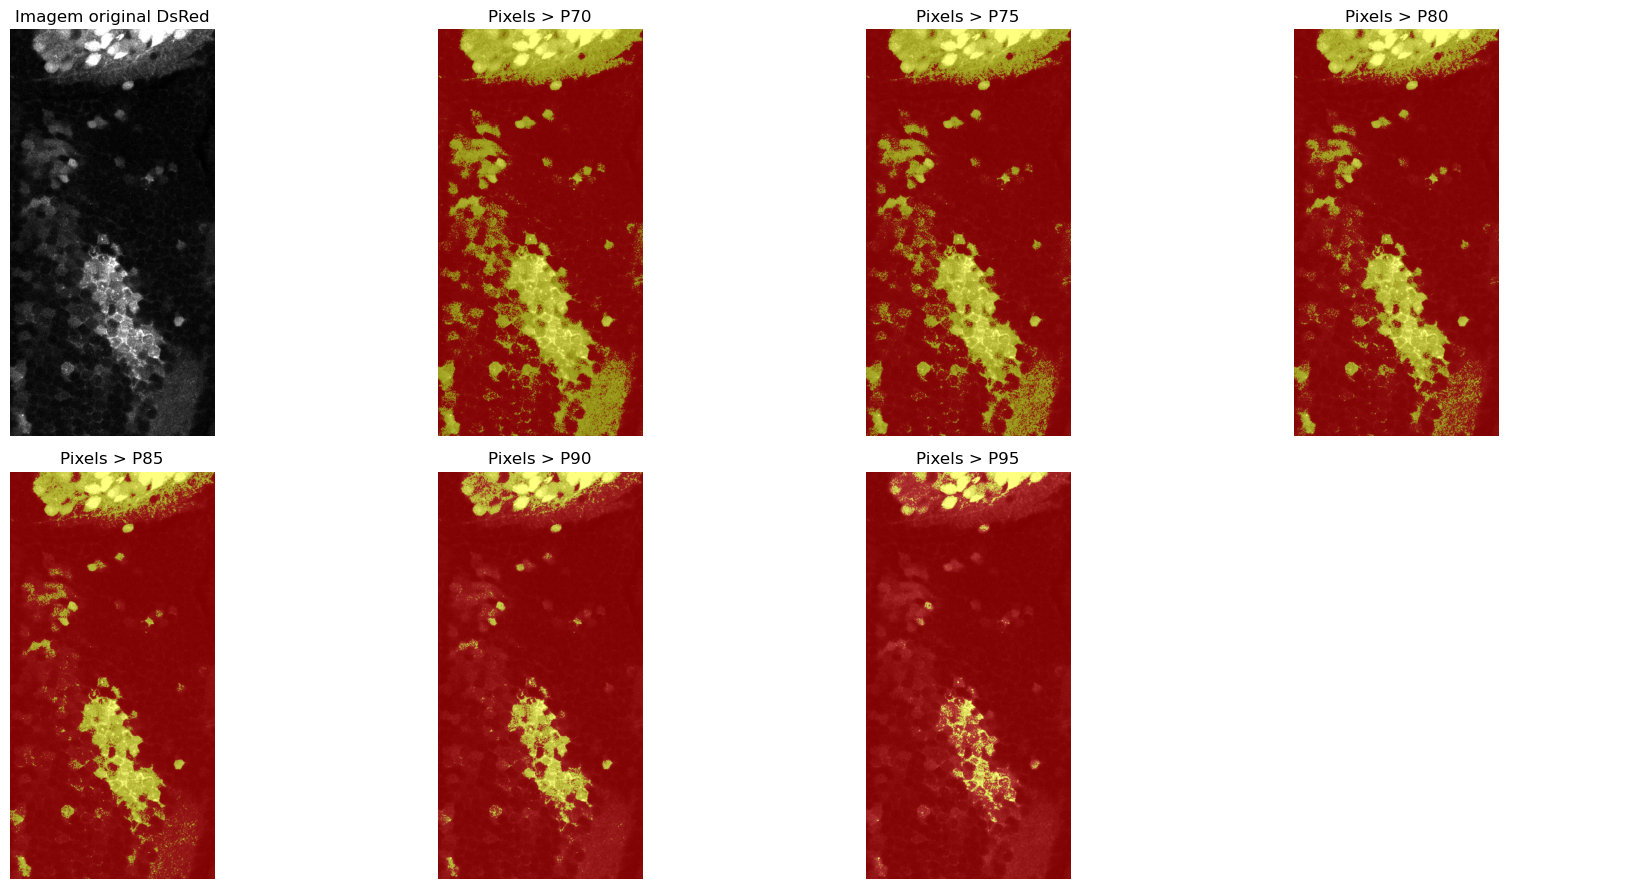

In [2]:
# ================== OVERLAY DE PERCENTIS DSRED (com imagem original) ==================
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

# -------- CONFIG (edita aqui) --------
IMG_PATH     = r"fish2may_halffish-Airyscan Processing_airyscandownsampledhindbrain.czi #3-2.tif"
LABELS_PATH  = r"fish2may_halffish-Airyscan Processing_airyscandownsampledhindbrain_onlynucleidenoisecyto3custommodel.czi #3-1_seg.npy"
Z            = 100               # slice desejada
DSRED_CHANNEL = 1                # índice do canal DsRed se for multi-canal

# -------- Funções auxiliares --------
EPS = 1e-9
def norm01(img):
    v1, v2 = np.percentile(img, (1,99))
    return np.clip((img - v1)/(v2 - v1 + EPS), 0, 1)

# -------- Carregar imagem --------
arr = tiff.imread(IMG_PATH)
a = np.asarray(arr)

# extrair canal DsRed e slice Z
if a.ndim == 4:
    if a.shape[-1] in (2,3,4):      # (Z,Y,X,C)
        dsred2d = a[Z, :, :, DSRED_CHANNEL].astype(np.float32)
    elif a.shape[0] in (2,3,4):     # (C,Z,Y,X)
        dsred2d = a[DSRED_CHANNEL, Z].astype(np.float32)
    elif a.shape[1] in (2,3,4):     # (Z,C,Y,X)
        dsred2d = a[Z, DSRED_CHANNEL].astype(np.float32)
    else:
        raise ValueError(f"Shape 4D inesperado: {a.shape}")
elif a.ndim == 3:
    dsred2d = a[Z].astype(np.float32)
else:
    raise ValueError(f"Shape inesperado: {a.shape}")

print(f"Imagem carregada: shape={dsred2d.shape}, Z={Z}")

# -------- Calcular percentis --------
percentis = [70, 75, 80, 85, 90, 95]
thr = {p: np.percentile(dsred2d, p) for p in percentis}

print("\nValores de percentil:")
for p, v in thr.items():
    print(f"  {p}th -> {v:.2f}")

# -------- Mostrar imagem original + overlays --------
img_n = norm01(dsred2d)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.ravel()

# painel 0 → imagem original
axes[0].imshow(img_n, cmap='gray')
axes[0].set_title('Imagem original DsRed')
axes[0].axis('off')

# painéis seguintes → overlays por percentil
for i, p in enumerate(percentis, start=1):
    mask = dsred2d > thr[p]
    axes[i].imshow(img_n, cmap='gray')
    axes[i].imshow(mask, cmap='autumn', alpha=0.5)  # overlay vermelho
    axes[i].set_title(f'Pixels > P{p}')
    axes[i].axis('off')

# esconder eixos extra (se houver)
for j in range(len(percentis)+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [3]:
# ================================================================
# DsRed 3D Classifier — Percentil 80 slice-wise + Brilho Central
# GPU (CuPy) ou CPU fallback
# ================================================================

import os, numpy as np, tifffile as tiff, matplotlib.pyplot as plt, pandas as pd
from skimage.filters import threshold_otsu
from skimage.measure import find_contours
from skimage.morphology import ball
from scipy.ndimage import binary_erosion, binary_dilation

# -------- GPU opcional --------
try:
    import cupy as cp
    from cupyx.scipy.ndimage import zoom as cp_zoom, mean as cp_mean
    GPU = True
    print("✅ GPU disponível (CuPy).")
except ImportError:
    from scipy.ndimage import zoom, mean as np_mean
    GPU = False
    print("⚠️ CuPy não encontrado, usando CPU.")

# -------- CONFIG --------
IMG_PATH  = r"fish2may_halffish-Airyscan Processing_airyscandownsampledhindbrain.czi #3-2.tif"
MASK_PATH = r"fish2may_halffish-Airyscan Processing_airyscandownsampledhindbrain_onlynucleidenoisecyto3custommodel.czi #3-1_seg.npy"
OUT_DIR   = r"C:\Users\OSVALDO\Music\outrossdsred_pipeline"
Z_SHOW    = 100
voxel_orig   = (0.30, 0.15, 0.15)  # (Z,Y,X)
voxel_target = (0.5, 0.5, 0.5)

# ================================================================
# 1️⃣ Carregar imagem (canal 1 fixo) e máscaras
# ================================================================
print("\n📂 A carregar imagem TIFF e máscaras...")

img = tiff.imread(IMG_PATH)
print("   Shape original:", img.shape)

if img.ndim == 4:
    if img.shape[-1] <= 4:
        dsred = img[..., 1].astype(np.float32)
    elif img.shape[0] <= 4:
        dsred = img[1].astype(np.float32)
    elif img.shape[1] <= 4:
        dsred = img[:, 1].astype(np.float32)
else:
    dsred = img.astype(np.float32)

labs_raw = np.load(MASK_PATH, allow_pickle=True)
if isinstance(labs_raw, np.ndarray) and labs_raw.dtype == object:
    labs_raw = labs_raw.item()
labels = labs_raw.get("masks", labs_raw.get("seg", labs_raw))
labels = np.asarray(labels, dtype=np.int32)

print("   ✅ DsRed:", dsred.shape, " |  Labels:", labels.shape)

# ================================================================
# 2️⃣ Reamostrar para 0.5 µm isotrópico
# ================================================================
print("\n🔄 Reamostragem isotrópica 0.5 µm...")
scales = tuple(o/t for o,t in zip(voxel_orig, voxel_target))
print("   Fatores:", scales)

if GPU:
    img_gpu = cp.asarray(dsred)
    lab_gpu = cp.asarray(labels)
    dsred_r = cp_zoom(img_gpu, zoom=scales, order=1)
    labels_r = cp_zoom(lab_gpu, zoom=scales, order=0)
    dsred_r, labels_r = cp.asnumpy(dsred_r), cp.asnumpy(labels_r)
else:
    dsred_r  = zoom(dsred,  zoom=scales, order=1)
    labels_r = zoom(labels, zoom=scales, order=0)

print("   ✅ Novo shape:", dsred_r.shape)

# ================================================================
# 3️⃣ Classificação base — percentil 80 slice-wise + Otsu
# ================================================================
print("\n📈 Classificação base (P80 slice-wise + Otsu)...")

if GPU:
    img_gpu = cp.asarray(dsred_r, dtype=cp.float32)
    lab_gpu = cp.asarray(labels_r, dtype=cp.int32)
    ids_gpu = cp.unique(lab_gpu)[1:]
    nZ = img_gpu.shape[0]

    frac_hi_list = []
    for z in range(nZ):
        plane = img_gpu[z]
        labels_z = lab_gpu[z]
        thr_z = float(cp.percentile(plane, 80))
        mask_hi = plane > thr_z
        frac_hi_z = cp_mean(mask_hi.astype(cp.float32), labels=labels_z, index=ids_gpu)
        frac_hi_list.append(frac_hi_z)

    frac_hi_gpu = cp.nanmean(cp.stack(frac_hi_list), axis=0)
    frac_hi, ids = cp.asnumpy(frac_hi_gpu), cp.asnumpy(ids_gpu)
else:
    ids = np.unique(labels_r)[1:]
    nZ = dsred_r.shape[0]
    frac_hi_all = []
    for z in range(nZ):
        thr_z = np.percentile(dsred_r[z], 80)
        mask_hi = dsred_r[z] > thr_z
        frac_z = [np.mean(mask_hi[labels_r[z]==i]) for i in ids]
        frac_hi_all.append(frac_z)
    frac_hi = np.nanmean(np.stack(frac_hi_all), axis=0)

thr_otsu = threshold_otsu(frac_hi)
DsRed_base = frac_hi > thr_otsu
print(f"   🔸 Limiar Otsu = {thr_otsu:.3f}  |  DsRed+ = {DsRed_base.sum()}/{len(ids)}")

# ================================================================
# 4️⃣ Refinamento rápido — bounding box + DsRed+ apenas (GPU)
# ================================================================
print("\n⚡ Refinamento rápido (bounding box + DsRed+ apenas)...")

if GPU:
    from cupyx.scipy.ndimage import distance_transform_edt, center_of_mass

    img_gpu = cp.asarray(dsred_r, dtype=cp.float32)
    lab_gpu = cp.asarray(labels_r, dtype=cp.int32)
    ids_gpu = cp.asarray(ids, dtype=cp.int32)
    mask_pos_gpu = cp.asarray(DsRed_base)

    ratio_center_gpu = cp.full_like(ids_gpu, cp.nan, dtype=cp.float32)

    # 🔹 Só processar células classificadas como DsRed+ pelo Otsu
    pos_labels = ids_gpu[mask_pos_gpu]

    for i in pos_labels:
        mask = (lab_gpu == i)
        if not cp.any(mask):
            continue

        # 🔹 Restringe o cálculo à bounding box da célula
        z, y, x = cp.where(mask)
        z0, z1 = int(z.min()), int(z.max()) + 1
        y0, y1 = int(y.min()), int(y.max()) + 1
        x0, x1 = int(x.min()), int(x.max()) + 1

        submask = mask[z0:z1, y0:y1, x0:x1]
        subimg  = img_gpu[z0:z1, y0:y1, x0:x1]

        # 🔹 Calcula distância apenas nessa sub-região
        dist = distance_transform_edt(submask)
        dmax = float(dist.max())
        if dmax < 2:
            continue

        core_mask = dist >= (2 * dmax / 3)
        peri_mask = (dist < (dmax / 3)) & submask

        if not cp.any(core_mask) or not cp.any(peri_mask):
            continue

        I_core = subimg[core_mask].mean()
        I_peri = subimg[peri_mask].mean()
        idx = cp.where(ids_gpu == i)[0][0]
        ratio_center_gpu[idx] = I_core / (I_peri + 1e-6)

    ratio_center = cp.asnumpy(ratio_center_gpu)

else:
    from scipy.ndimage import distance_transform_edt, center_of_mass
    ratio_center = np.full(len(ids), np.nan, dtype=np.float32)

    pos_labels = ids[DsRed_base]

    for i in pos_labels:
        mask = (labels_r == i)
        if not np.any(mask):
            continue

        z, y, x = np.where(mask)
        z0, z1 = int(z.min()), int(z.max()) + 1
        y0, y1 = int(y.min()), int(y.max()) + 1
        x0, x1 = int(x.min()), int(x.max()) + 1

        submask = mask[z0:z1, y0:y1, x0:x1]
        subimg  = dsred_r[z0:z1, y0:y1, x0:x1]

        dist = distance_transform_edt(submask)
        dmax = float(dist.max())
        if dmax < 2:
            continue

        core_mask = dist >= (2 * dmax / 3)
        peri_mask = (dist < (dmax / 3)) & submask

        if not np.any(core_mask) or not np.any(peri_mask):
            continue

        I_core = subimg[core_mask].mean()
        I_peri = subimg[peri_mask].mean()
        idx = np.where(ids == i)[0][0]
        ratio_center[idx] = I_core / (I_peri + 1e-6)

# -------- Classificação refinada --------
DsRed_refined = (DsRed_base) & (ratio_center > 1.3)
print(f"   ✅ Refinamento concluído: {np.sum(DsRed_refined)} / {len(ids)} positivas")
print("   💠 GPU memory in use:", round(cp.get_default_memory_pool().used_bytes() / 1e9, 2), "GB")


# Classificação refinada
DsRed_refined = (DsRed_base) & (ratio_center > 1.3)

print(f"   ✅ Refinamento rápido concluído: {np.sum(DsRed_refined)} / {len(ids)} positivas")
print("   💠 GPU memory in use:", round(cp.get_default_memory_pool().used_bytes() / 1e9, 2), "GB")

# ================================================================
# 5️⃣ Guardar resultados
# ================================================================
df = pd.DataFrame({
    "label": ids,
    "frac_hi": frac_hi,
    "ratio_center": ratio_center,
    "DsRed_base": DsRed_base,
    "DsRed_refined": DsRed_refined
})
os.makedirs(OUT_DIR, exist_ok=True)
csv_path = os.path.join(OUT_DIR, "DsRed_comparison.csv")
df.to_csv(csv_path, index=False)
print(f"💾 CSV salvo em: {csv_path}")


✅ GPU disponível (CuPy).

📂 A carregar imagem TIFF e máscaras...
   Shape original: (291, 3, 1805, 905)
   ✅ DsRed: (291, 1805, 905)  |  Labels: (291, 1805, 905)

🔄 Reamostragem isotrópica 0.5 µm...
   Fatores: (0.6, 0.3, 0.3)
   ✅ Novo shape: (175, 542, 272)

📈 Classificação base (P80 slice-wise + Otsu)...
   🔸 Limiar Otsu = 0.443  |  DsRed+ = 2035/9901

⚡ Refinamento rápido (bounding box + DsRed+ apenas)...
   ✅ Refinamento concluído: 261 / 9901 positivas
   💠 GPU memory in use: 0.56 GB
   ✅ Refinamento rápido concluído: 261 / 9901 positivas
   💠 GPU memory in use: 0.56 GB


PermissionError: [WinError 5] Access is denied: 'C:\\Users\\OSVALDO'


📊 A gerar gráficos e visualizações...


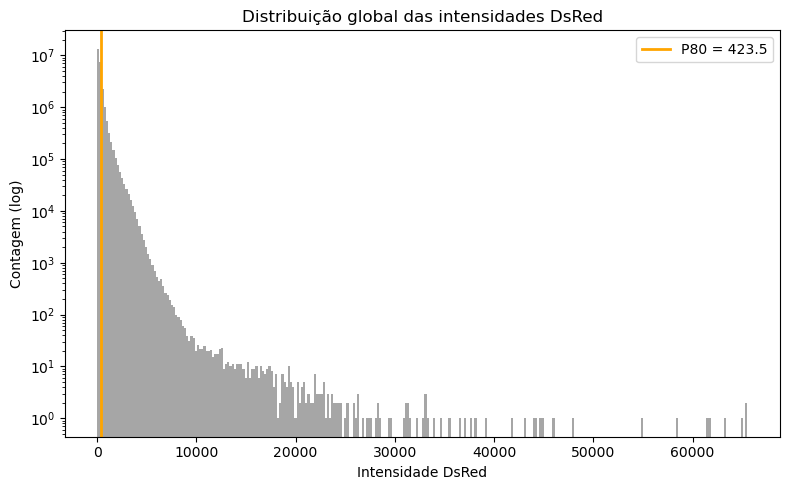

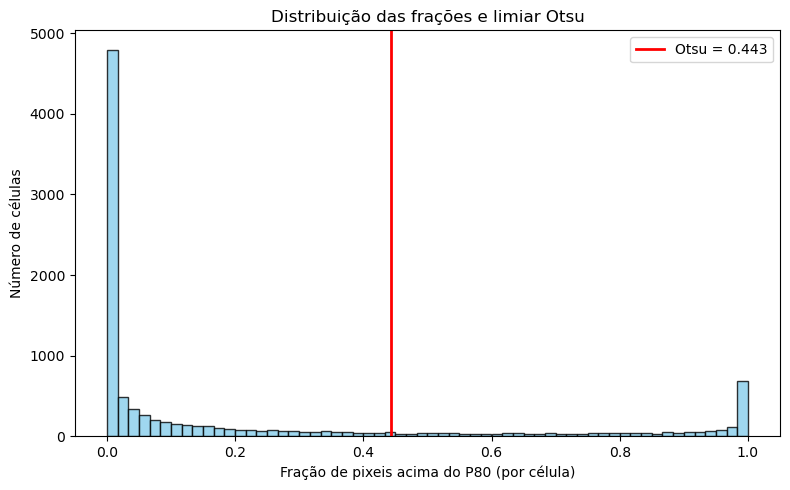

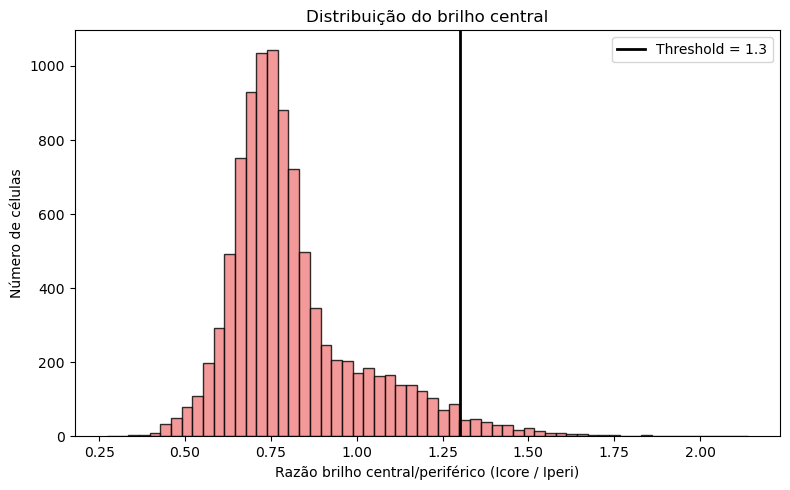

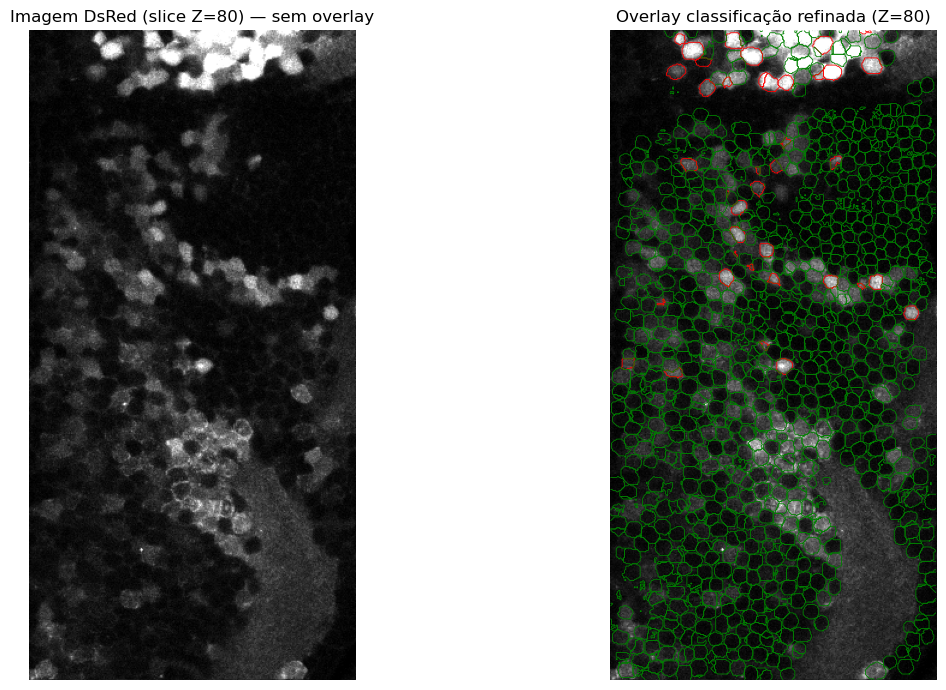


✅ Gráficos e visualizações concluídos.


In [2]:
# ================================================================
# 7️⃣ Visualizações e análise dos thresholds
# ================================================================
print("\n📊 A gerar gráficos e visualizações...")

def normalize01(a):
    p1, p99 = np.percentile(a, (1, 99))
    return np.clip((a - p1) / (p99 - p1 + 1e-9), 0, 1)

# -------- 1️⃣ Histograma das intensidades globais (P80 marcado) --------
intens = dsred_r.flatten()
p80 = np.percentile(intens, 80)

plt.figure(figsize=(8, 5))
plt.hist(intens, bins=300, color="gray", alpha=0.7, log=True)
plt.axvline(p80, color="orange", lw=2, label=f"P80 = {p80:.1f}")
plt.xlabel("Intensidade DsRed")
plt.ylabel("Contagem (log)")
plt.title("Distribuição global das intensidades DsRed")
plt.legend()
plt.tight_layout()
plt.show()

# -------- 2️⃣ Histograma da fração acima do P80 (Otsu) --------
plt.figure(figsize=(8, 5))
plt.hist(df["frac_hi"], bins=60, color="skyblue", edgecolor="k", alpha=0.8)
plt.axvline(thr_otsu, color="red", lw=2, label=f"Otsu = {thr_otsu:.3f}")
plt.xlabel("Fração de pixeis acima do P80 (por célula)")
plt.ylabel("Número de células")
plt.title("Distribuição das frações e limiar Otsu")
plt.legend()
plt.tight_layout()
plt.show()

# -------- 3️⃣ Histograma do brilho central (ratio_center) --------
valid = np.isfinite(ratio_center)
plt.figure(figsize=(8, 5))
plt.hist(ratio_center[valid], bins=60, color="lightcoral", edgecolor="k", alpha=0.8)
plt.axvline(1.3, color="black", lw=2, label="Threshold = 1.3")
plt.xlabel("Razão brilho central/periférico (Icore / Iperi)")
plt.ylabel("Número de células")
plt.title("Distribuição do brilho central")
plt.legend()
plt.tight_layout()
plt.show()

# -------- 4️⃣ Imagem bruta vs overlay (refinado) --------
Z = 80  # slice para visualização
Z = min(Z, dsred_r.shape[0] - 1)

img_raw = normalize01(dsred_r[Z])

fig, ax = plt.subplots(1, 2, figsize=(14, 7))
ax[0].imshow(img_raw, cmap="gray")
ax[0].set_title(f"Imagem DsRed (slice Z={Z}) — sem overlay")
ax[0].axis("off")

ax[1].imshow(img_raw, cmap="gray")
for r in df.itertuples():
    color = "red" if r.DsRed_refined else "green"
    mask = labels_r[Z] == r.label
    for c in find_contours(mask, 0.5):
        ax[1].plot(c[:, 1], c[:, 0], color=color, lw=0.6)
ax[1].set_title(f"Overlay classificação refinada (Z={Z})")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print("\n✅ Gráficos e visualizações concluídos.")


✅ GPU available (CuPy).

📂 Loading TIFF image and masks...
   Original shape: (291, 3, 1805, 905)
   ✅ DsRed: (291, 1805, 905)  |  Labels: (291, 1805, 905)

🔄 Isotropic resampling to 0.5 µm...
   Scale factors: (0.6, 0.3, 0.3)
   ✅ New shape: (175, 542, 272)

📈 Base classification (P70 slice-wise + Otsu)...
   🔸 Otsu threshold = 0.471  |  DsRed+ = 2760/9901

⚡ Refinement (bounding box + DsRed+ only)...
   ✅ Refinement done: 1365 / 9901 positives (threshold=1.0)
   💠 GPU memory in use: 0.56 GB
💾 CSV saved to: D:\User data\InesMarques\2025-09-01\outcrossdsred\codigo\DsRed_comparison_P70_thr1.0.csv

🖼️ Generating Base vs Refined overlays...


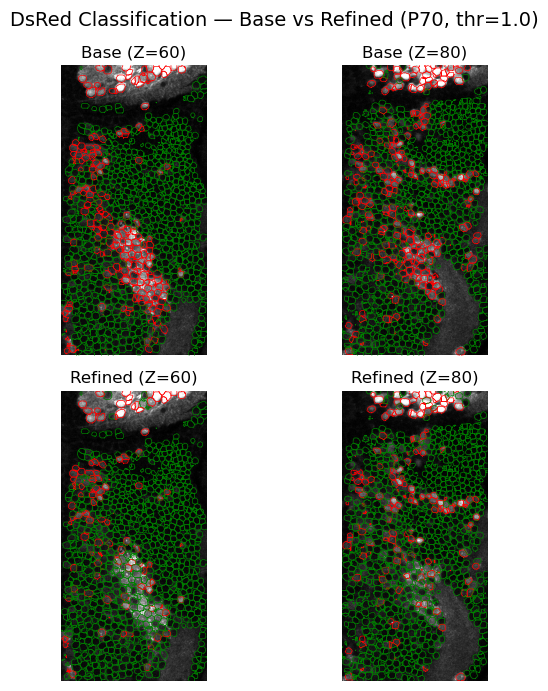


✅ Overlay comparison completed.


In [5]:
# ================================================================
# DsRed 3D Classifier — Percentile 70 slice-wise + Central Brightness
# Optimized GPU version with bounding-box refinement and visualizations
# ================================================================

import os, numpy as np, tifffile as tiff, matplotlib.pyplot as plt, pandas as pd
from skimage.filters import threshold_otsu
from skimage.measure import find_contours

# -------- GPU optional --------
try:
    import cupy as cp
    from cupyx.scipy.ndimage import zoom as cp_zoom, mean as cp_mean
    GPU = True
    print("✅ GPU available (CuPy).")
except ImportError:
    from scipy.ndimage import zoom, mean as np_mean
    GPU = False
    print("⚠️ CuPy not found, using CPU.")

# -------- CONFIG --------
IMG_PATH  = r"fish2may_halffish-Airyscan Processing_airyscandownsampledhindbrain.czi #3-2.tif"
MASK_PATH = r"fish2may_halffish-Airyscan Processing_airyscandownsampledhindbrain_onlynucleidenoisecyto3custommodel.czi #3-1_seg.npy"
OUT_DIR   = r"D:\User data\InesMarques\2025-09-01\outcrossdsred\codigo"
Z_SHOWS   = [60, 80]
voxel_orig   = (0.30, 0.15, 0.15)  # (Z,Y,X)
voxel_target = (0.5, 0.5, 0.5)
PERCENTILE = 70
RATIO_THR  = 1.0  # changed from 1.3 → 1.0

# ================================================================
# 1️⃣ Load image (fixed DsRed channel) and masks
# ================================================================
print("\n📂 Loading TIFF image and masks...")

img = tiff.imread(IMG_PATH)
print("   Original shape:", img.shape)

if img.ndim == 4:
    if img.shape[-1] <= 4:
        dsred = img[..., 1].astype(np.float32)
    elif img.shape[0] <= 4:
        dsred = img[1].astype(np.float32)
    elif img.shape[1] <= 4:
        dsred = img[:, 1].astype(np.float32)
else:
    dsred = img.astype(np.float32)

labs_raw = np.load(MASK_PATH, allow_pickle=True)
if isinstance(labs_raw, np.ndarray) and labs_raw.dtype == object:
    labs_raw = labs_raw.item()
labels = labs_raw.get("masks", labs_raw.get("seg", labs_raw))
labels = np.asarray(labels, dtype=np.int32)

print("   ✅ DsRed:", dsred.shape, " |  Labels:", labels.shape)

# ================================================================
# 2️⃣ Resample to 0.5 µm isotropic
# ================================================================
print("\n🔄 Isotropic resampling to 0.5 µm...")
scales = tuple(o/t for o,t in zip(voxel_orig, voxel_target))
print("   Scale factors:", scales)

if GPU:
    img_gpu = cp.asarray(dsred)
    lab_gpu = cp.asarray(labels)
    dsred_r = cp_zoom(img_gpu, zoom=scales, order=1)
    labels_r = cp_zoom(lab_gpu, zoom=scales, order=0)
    dsred_r, labels_r = cp.asnumpy(dsred_r), cp.asnumpy(labels_r)
else:
    from scipy.ndimage import zoom
    dsred_r  = zoom(dsred,  zoom=scales, order=1)
    labels_r = zoom(labels, zoom=scales, order=0)

print("   ✅ New shape:", dsred_r.shape)

# ================================================================
# 3️⃣ Base classification — Percentile 70 slice-wise + Otsu
# ================================================================
print(f"\n📈 Base classification (P{PERCENTILE} slice-wise + Otsu)...")

if GPU:
    img_gpu = cp.asarray(dsred_r, dtype=cp.float32)
    lab_gpu = cp.asarray(labels_r, dtype=cp.int32)
    ids_gpu = cp.unique(lab_gpu)[1:]
    nZ = img_gpu.shape[0]

    frac_hi_list = []
    for z in range(nZ):
        plane = img_gpu[z]
        labels_z = lab_gpu[z]
        thr_z = float(cp.percentile(plane, PERCENTILE))
        mask_hi = plane > thr_z
        frac_hi_z = cp_mean(mask_hi.astype(cp.float32), labels=labels_z, index=ids_gpu)
        frac_hi_list.append(frac_hi_z)

    frac_hi_gpu = cp.nanmean(cp.stack(frac_hi_list), axis=0)
    frac_hi, ids = cp.asnumpy(frac_hi_gpu), cp.asnumpy(ids_gpu)
else:
    ids = np.unique(labels_r)[1:]
    nZ = dsred_r.shape[0]
    frac_hi_all = []
    for z in range(nZ):
        thr_z = np.percentile(dsred_r[z], PERCENTILE)
        mask_hi = dsred_r[z] > thr_z
        frac_z = [np.mean(mask_hi[labels_r[z]==i]) for i in ids]
        frac_hi_all.append(frac_z)
    frac_hi = np.nanmean(np.stack(frac_hi_all), axis=0)

thr_otsu = threshold_otsu(frac_hi)
DsRed_base = frac_hi > thr_otsu
print(f"   🔸 Otsu threshold = {thr_otsu:.3f}  |  DsRed+ = {DsRed_base.sum()}/{len(ids)}")

# ================================================================
# 4️⃣ Refinement — bounding box + DsRed+ only (GPU)
# ================================================================
print("\n⚡ Refinement (bounding box + DsRed+ only)...")

if GPU:
    from cupyx.scipy.ndimage import distance_transform_edt

    img_gpu = cp.asarray(dsred_r, dtype=cp.float32)
    lab_gpu = cp.asarray(labels_r, dtype=cp.int32)
    ids_gpu = cp.asarray(ids, dtype=cp.int32)
    mask_pos_gpu = cp.asarray(DsRed_base)

    ratio_center_gpu = cp.full_like(ids_gpu, cp.nan, dtype=cp.float32)
    pos_labels = ids_gpu[mask_pos_gpu]

    for i in pos_labels:
        mask = (lab_gpu == i)
        if not cp.any(mask):
            continue

        z, y, x = cp.where(mask)
        z0, z1 = int(z.min()), int(z.max()) + 1
        y0, y1 = int(y.min()), int(y.max()) + 1
        x0, x1 = int(x.min()), int(x.max()) + 1

        submask = mask[z0:z1, y0:y1, x0:x1]
        subimg  = img_gpu[z0:z1, y0:y1, x0:x1]

        dist = distance_transform_edt(submask)
        dmax = float(dist.max())
        if dmax < 2:
            continue

        core_mask = dist >= (2 * dmax / 3)
        peri_mask = (dist < (dmax / 3)) & submask

        if not cp.any(core_mask) or not cp.any(peri_mask):
            continue

        I_core = subimg[core_mask].mean()
        I_peri = subimg[peri_mask].mean()
        idx = cp.where(ids_gpu == i)[0][0]
        ratio_center_gpu[idx] = I_core / (I_peri + 1e-6)

    ratio_center = cp.asnumpy(ratio_center_gpu)
else:
    from scipy.ndimage import distance_transform_edt
    ratio_center = np.full(len(ids), np.nan, dtype=np.float32)
    pos_labels = ids[DsRed_base]
    for i in pos_labels:
        mask = (labels_r == i)
        if not np.any(mask):
            continue
        z, y, x = np.where(mask)
        z0, z1 = int(z.min()), int(z.max()) + 1
        y0, y1 = int(y.min()), int(y.max()) + 1
        x0, x1 = int(x.min()), int(x.max()) + 1
        submask = mask[z0:z1, y0:y1, x0:x1]
        subimg  = dsred_r[z0:z1, y0:y1, x0:x1]
        dist = distance_transform_edt(submask)
        dmax = float(dist.max())
        if dmax < 2:
            continue
        core_mask = dist >= (2 * dmax / 3)
        peri_mask = (dist < (dmax / 3)) & submask
        if not np.any(core_mask) or not np.any(peri_mask):
            continue
        I_core = subimg[core_mask].mean()
        I_peri = subimg[peri_mask].mean()
        idx = np.where(ids == i)[0][0]
        ratio_center[idx] = I_core / (I_peri + 1e-6)

DsRed_refined = (DsRed_base) & (ratio_center > RATIO_THR)
print(f"   ✅ Refinement done: {np.sum(DsRed_refined)} / {len(ids)} positives (threshold={RATIO_THR})")
if GPU:
    print("   💠 GPU memory in use:", round(cp.get_default_memory_pool().used_bytes() / 1e9, 2), "GB")

# ================================================================
# 5️⃣ Save results
# ================================================================
df = pd.DataFrame({
    "label": ids,
    "frac_hi": frac_hi,
    "ratio_center": ratio_center,
    "DsRed_base": DsRed_base,
    "DsRed_refined": DsRed_refined
})
os.makedirs(OUT_DIR, exist_ok=True)
csv_path = os.path.join(OUT_DIR, f"DsRed_comparison_P{PERCENTILE}_thr{RATIO_THR}.csv")
df.to_csv(csv_path, index=False)
print(f"💾 CSV saved to: {csv_path}")

# ================================================================
# 6️⃣ Overlay comparison — before vs after refinement
# ================================================================
print("\n🖼️ Generating Base vs Refined overlays...")

def normalize01(a):
    p1, p99 = np.percentile(a, (1, 99))
    return np.clip((a - p1) / (p99 - p1 + 1e-9), 0, 1)

fig, axes = plt.subplots(2, len(Z_SHOWS), figsize=(3.5 * len(Z_SHOWS), 7))
for j, Z in enumerate(Z_SHOWS):
    if Z >= dsred_r.shape[0]:
        continue
    img_raw = normalize01(dsred_r[Z])

    # --- Base classification overlay ---
    ax1 = axes[0, j]
    ax1.imshow(img_raw, cmap="gray")
    for r in df.itertuples():
        color = "red" if r.DsRed_base else "green"
        mask = labels_r[Z] == r.label
        for c in find_contours(mask, 0.5):
            ax1.plot(c[:, 1], c[:, 0], color=color, lw=0.5)
    ax1.set_title(f"Base (Z={Z})")
    ax1.axis("off")

    # --- Refined classification overlay ---
    ax2 = axes[1, j]
    ax2.imshow(img_raw, cmap="gray")
    for r in df.itertuples():
        color = "red" if r.DsRed_refined else "green"
        mask = labels_r[Z] == r.label
        for c in find_contours(mask, 0.5):
            ax2.plot(c[:, 1], c[:, 0], color=color, lw=0.5)
    ax2.set_title(f"Refined (Z={Z})")
    ax2.axis("off")

plt.suptitle(f"DsRed Classification — Base vs Refined (P{PERCENTILE}, thr={RATIO_THR})", fontsize=14)
plt.tight_layout()
plt.show()

print("\n✅ Overlay comparison completed.")




📈 Generating slice-wise analysis...


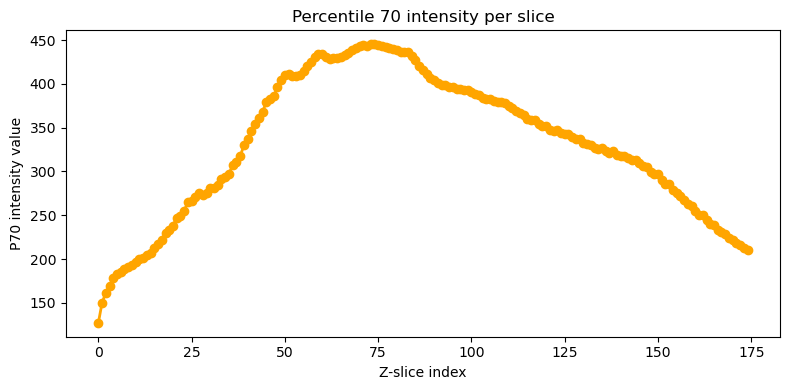

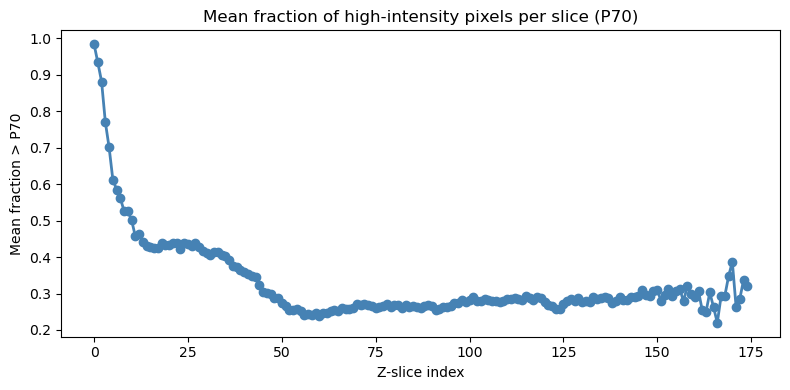

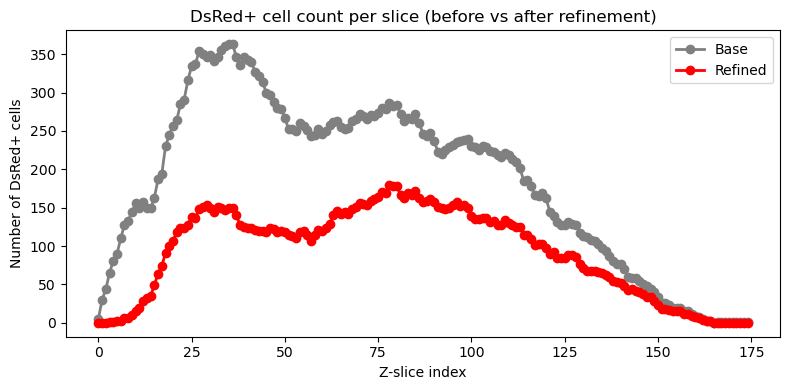

✅ Slice-wise plots completed.


In [6]:
# ================================================================
# 7️⃣ Slice-wise analysis and plots
# ================================================================
print("\n📈 Generating slice-wise analysis...")

nZ = dsred_r.shape[0]
p70_slices = []
frac_mean_slices = []
cells_base_slices = []
cells_refined_slices = []

# Loop through slices
for z in range(nZ):
    plane = dsred_r[z]
    thr_z = np.percentile(plane, PERCENTILE)
    p70_slices.append(thr_z)

    # Fraction of pixels > P70 per cell
    mask_hi = plane > thr_z
    frac_z = []
    for i in np.unique(labels_r[z])[1:]:
        frac_z.append(np.mean(mask_hi[labels_r[z]==i]))
    frac_mean_slices.append(np.mean(frac_z))

    # Count of DsRed+ cells in this slice
    mask_z = labels_r[z]
    ids_z = np.unique(mask_z)[1:]
    pos_base = sum([(i in ids[df["DsRed_base"]]) for i in ids_z])
    pos_ref  = sum([(i in ids[df["DsRed_refined"]]) for i in ids_z])
    cells_base_slices.append(pos_base)
    cells_refined_slices.append(pos_ref)

# Convert to arrays
p70_slices = np.array(p70_slices)
frac_mean_slices = np.array(frac_mean_slices)
cells_base_slices = np.array(cells_base_slices)
cells_refined_slices = np.array(cells_refined_slices)

# -------- 1️⃣ Percentile 70 per slice --------
plt.figure(figsize=(8,4))
plt.plot(range(nZ), p70_slices, '-o', color='orange', lw=2)
plt.xlabel("Z-slice index")
plt.ylabel("P70 intensity value")
plt.title(f"Percentile {PERCENTILE} intensity per slice")
plt.tight_layout()
plt.show()

# -------- 2️⃣ Mean fraction of high pixels --------
plt.figure(figsize=(8,4))
plt.plot(range(nZ), frac_mean_slices, '-o', color='steelblue', lw=2)
plt.xlabel("Z-slice index")
plt.ylabel(f"Mean fraction > P{PERCENTILE}")
plt.title(f"Mean fraction of high-intensity pixels per slice (P{PERCENTILE})")
plt.tight_layout()
plt.show()

# -------- 3️⃣ DsRed+ cells per slice --------
plt.figure(figsize=(8,4))
plt.plot(range(nZ), cells_base_slices, '-o', color='gray', lw=2, label='Base')
plt.plot(range(nZ), cells_refined_slices, '-o', color='red', lw=2, label='Refined')
plt.xlabel("Z-slice index")
plt.ylabel("Number of DsRed+ cells")
plt.title("DsRed+ cell count per slice (before vs after refinement)")
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Slice-wise plots completed.")


With new stacks(dsred without in situ)

✅ GPU available (CuPy). Using GPU for volume computation.

📂 Loading image and mask...
   Image shape: (400, 3, 1638, 1638)
   Mask shape: (400, 1638, 1638)

📦 Computing mask volumes...
   ✅ Computed on GPU (5383 masks).
   Volume range: 31.4–1025.2 µm³ (median 442.4)


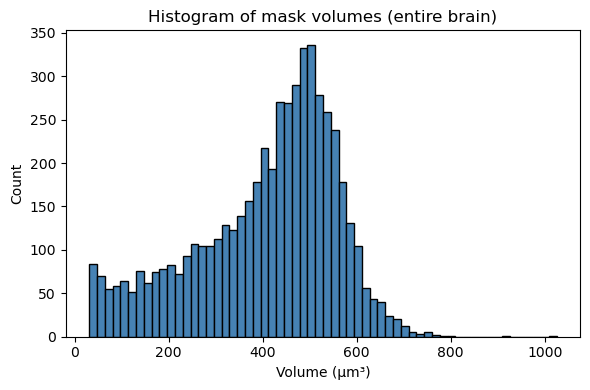


🧠 Displaying example slice (three channels)...


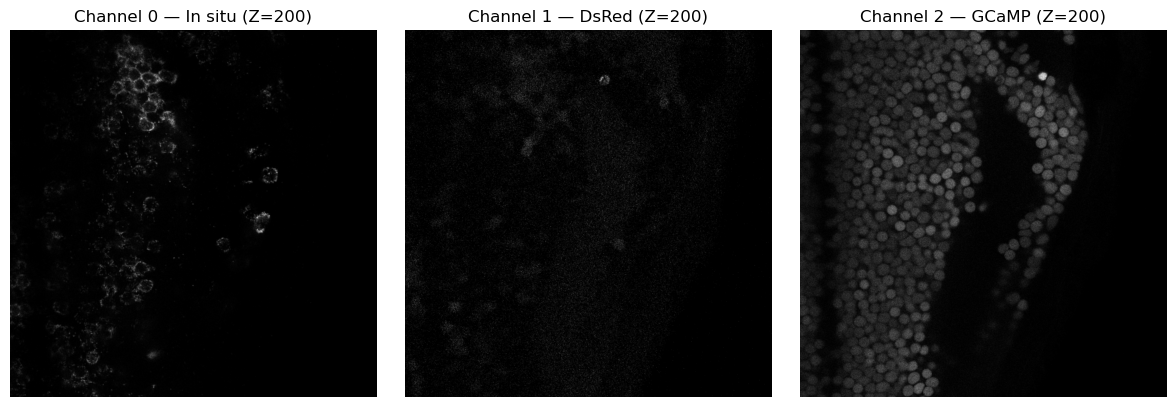


✅ Done: channels displayed and volume histogram generated.


In [ ]:
# ================================================================
# Volume & Channel Visualization Script (Inês Marques) — GPU version
# Shows Channel 0 (in situ), Channel 1 (DsRed), Channel 2 (GCaMP)
# Computes 3D mask volumes using GPU (CuPy) and plots histogram
# ================================================================

import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import os

# Try to use GPU
try:
    import cupy as cp
    GPU = True
    print("✅ GPU available (CuPy). Using GPU for volume computation.")
except ImportError:
    GPU = False
    print("⚠️ CuPy not found, using CPU (NumPy).")

# -------- CONFIG --------
IMG_PATH  = r"D:\User data\InesMarques\202501024\fish5good\fish5wholebraingood_airyscan.czi - fish5wholebraingood_airyscantile10hindbrain_400slices.tif"
MASK_PATH = r"D:\User data\InesMarques\202501024\fish5good\fish5wholebraingood_airyscan.czi - fish5wholebraingood_airyscantile10hindbrain_400slices_onlynucleihindbrain3D_cyto3.tif"

# Voxel size (µm)
voxel_size = (0.25, 0.1, 0.1)  # (Z, Y, X)
voxel_volume = np.prod(voxel_size)

# -------- LOAD IMAGE --------
print("\n📂 Loading image and mask...")
img = tiff.imread(IMG_PATH)
print("   Image shape:", img.shape)

if img.ndim != 4 or img.shape[1] < 3:
    raise ValueError("⚠️ Expected image shape (Z, C, Y, X) with at least 3 channels.")

# Separate channels
chan0 = img[:, 0, :, :].astype(np.float32)  # in situ
chan1 = img[:, 1, :, :].astype(np.float32)  # DsRed
chan2 = img[:, 2, :, :].astype(np.float32)  # GCaMP

# Load mask
labels = tiff.imread(MASK_PATH).astype(np.int32)
print("   Mask shape:", labels.shape)

# -------- COMPUTE MASK VOLUMES --------
print("\n📦 Computing mask volumes...")

if GPU:
    # Move masks to GPU
    labels_gpu = cp.asarray(labels)
    unique_ids_gpu = cp.unique(labels_gpu)
    unique_ids_gpu = unique_ids_gpu[unique_ids_gpu > 0]

    # Count voxels per label in one step (fast)
    counts_gpu = cp.bincount(labels_gpu.ravel())
    counts_gpu = counts_gpu[unique_ids_gpu]
    volumes_gpu = counts_gpu * voxel_volume

    # Move back to CPU for plotting
    unique_ids = cp.asnumpy(unique_ids_gpu)
    volumes = cp.asnumpy(volumes_gpu)

    print(f"   ✅ Computed on GPU ({len(unique_ids)} masks).")
else:
    unique_ids = np.unique(labels)
    unique_ids = unique_ids[unique_ids > 0]
    volumes = np.array([(labels == i).sum() * voxel_volume for i in unique_ids])
    print(f"   ✅ Computed on CPU ({len(unique_ids)} masks).")

print(f"   Volume range: {volumes.min():.1f}–{volumes.max():.1f} µm³ (median {np.median(volumes):.1f})")

# -------- PLOT HISTOGRAM --------
plt.figure(figsize=(6, 4))
plt.hist(volumes, bins=60, color="steelblue", edgecolor="black")
plt.xlabel("Volume (µm³)")
plt.ylabel("Count")
plt.title("Histogram of mask volumes (entire brain)")
plt.tight_layout()
plt.show()

# -------- SHOW CHANNELS SIDE BY SIDE --------
print("\n🧠 Displaying example slice (three channels)...")

zshow = labels.shape[0] // 2  # central slice
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(chan0[zshow], cmap="gray")
ax[0].set_title(f"Channel 0 — In situ (Z={zshow})")
ax[0].axis("off")
ax[1].imshow(chan1[zshow], cmap="gray")
ax[1].set_title(f"Channel 1 — DsRed (Z={zshow})")
ax[1].axis("off")
ax[2].imshow(chan2[zshow], cmap="gray")
ax[2].set_title(f"Channel 2 — GCaMP (Z={zshow})")
ax[2].axis("off")
plt.tight_layout()
plt.show()

print("\n✅ Done: channels displayed and volume histogram generated.")




✅ GPU available (CuPy). Using CUDA acceleration.

📂 Loading image and mask...
   Image shape: (400, 3, 1638, 1638)
   Mask shape:  (400, 1638, 1638)
   Load time: 9.08 s

📦 Computing mask volumes...
   ✅ Computed on GPU (5383 masks).
   Volume range: 5.03–164.04 µm³ (median 70.78)
   ⏱️ Volume computation took 15.26 s

🧩 Computing number of Z-slices per mask (GPU block-wise)...
   Z-slice range: 1–3 (median 2.0)
   ⏱️ Slice computation took 4.62 s
   Physical thickness range: 0.25–0.75 µm (median 0.50)


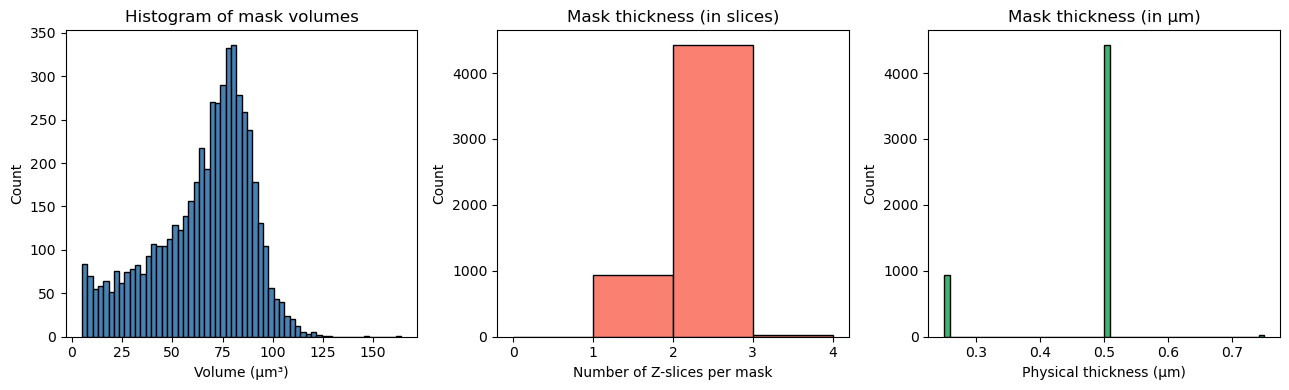

💾 Results saved to: D:\User data\InesMarques\202501024\fish5good\fish5wholebraingood_airyscan.czi - fish5wholebraingood_airyscantile10hindbrain_400slices_onlynucleihindbrain3D_cyto3_mask_volumes_slices.csv

✅ Done! Full GPU computation completed successfully.


In [1]:
# ================================================================
# Volume & Slice Thickness Visualization — Full GPU optimized version
# Computes 3D mask volumes (µm³) and number of Z-slices per mask
# Uses block-wise GPU computation to maintain continuous CUDA load
# ================================================================

import numpy as np
import tifffile as tiff
import matplotlib.pyplot as plt
import os
import time

# -------- Try GPU --------
try:
    import cupy as cp
    GPU = True
    print("✅ GPU available (CuPy). Using CUDA acceleration.")
except ImportError:
    GPU = False
    print("⚠️ CuPy not found, falling back to CPU (slower).")

# -------- CONFIG --------
IMG_PATH  = r"D:\User data\InesMarques\202501024\fish5good\fish5wholebraingood_airyscan.czi - fish5wholebraingood_airyscantile10hindbrain_400slices.tif"
MASK_PATH = r"D:\User data\InesMarques\202501024\fish5good\fish5wholebraingood_airyscan.czi - fish5wholebraingood_airyscantile10hindbrain_400slices_onlynucleihindbrain3D_cyto3.tif"

# ⚠️ Voxel size in µm (Z, Y, X)
voxel_size = (0.25, 0.10, 0.10)
voxel_volume = np.prod(voxel_size)

# -------- LOAD IMAGE & MASK --------
print("\n📂 Loading image and mask...")
t0 = time.time()
img = tiff.imread(IMG_PATH)
labels = tiff.imread(MASK_PATH).astype(np.int32)
print(f"   Image shape: {img.shape}")
print(f"   Mask shape:  {labels.shape}")
print(f"   Load time: {time.time() - t0:.2f} s")

# ================================================================
# 1️⃣ Compute mask volumes (GPU)
# ================================================================
print("\n📦 Computing mask volumes...")
t0 = time.time()

if GPU:
    labels_gpu = cp.asarray(labels)
    unique_ids_gpu = cp.unique(labels_gpu)
    unique_ids_gpu = unique_ids_gpu[unique_ids_gpu > 0]

    counts_gpu = cp.bincount(labels_gpu.ravel())
    counts_gpu = counts_gpu[unique_ids_gpu]
    volumes_gpu = counts_gpu * voxel_volume

    unique_ids = cp.asnumpy(unique_ids_gpu)
    volumes = cp.asnumpy(volumes_gpu)

    print(f"   ✅ Computed on GPU ({len(unique_ids)} masks).")
else:
    unique_ids = np.unique(labels)
    unique_ids = unique_ids[unique_ids > 0]
    volumes = np.array([(labels == i).sum() * voxel_volume for i in unique_ids])
    print(f"   ✅ Computed on CPU ({len(unique_ids)} masks).")

print(f"   Volume range: {volumes.min():.2f}–{volumes.max():.2f} µm³ (median {np.median(volumes):.2f})")
print(f"   ⏱️ Volume computation took {time.time() - t0:.2f} s")

# ================================================================
# 2️⃣ Compute number of Z-slices per mask (GPU block-wise)
# ================================================================
print("\n🧩 Computing number of Z-slices per mask (GPU block-wise)...")
t0 = time.time()

if GPU:
    z_counts_gpu = cp.zeros(int(labels_gpu.max()) + 1, dtype=cp.int32)

    step = 25  # process 25 slices at a time to maintain CUDA load
    for z0 in range(0, labels_gpu.shape[0], step):
        z1 = min(z0 + step, labels_gpu.shape[0])
        block = labels_gpu[z0:z1]

        present_gpu = cp.unique(block)
        present_gpu = present_gpu[present_gpu > 0]

        if present_gpu.size > 0:
            # increment each label count by number of slices it appears in this block
            slice_presence = cp.bincount(present_gpu, minlength=z_counts_gpu.size)
            z_counts_gpu += slice_presence

    z_counts_gpu = z_counts_gpu[unique_ids_gpu]
    num_slices = cp.asnumpy(z_counts_gpu)
else:
    num_slices = np.array([
        np.count_nonzero(np.any(labels == i, axis=(1, 2))) for i in unique_ids
    ])

print(f"   Z-slice range: {num_slices.min()}–{num_slices.max()} (median {np.median(num_slices)})")
print(f"   ⏱️ Slice computation took {time.time() - t0:.2f} s")

# ================================================================
# 3️⃣ Compute physical thickness (µm)
# ================================================================
thickness_um = num_slices * voxel_size[0]
print(f"   Physical thickness range: {thickness_um.min():.2f}–{thickness_um.max():.2f} µm (median {np.median(thickness_um):.2f})")

# ================================================================
# 4️⃣ Plot histograms
# ================================================================
plt.figure(figsize=(13, 4))
plt.subplot(1, 3, 1)
plt.hist(volumes, bins=60, color="steelblue", edgecolor="black")
plt.xlabel("Volume (µm³)")
plt.ylabel("Count")
plt.title("Histogram of mask volumes")

plt.subplot(1, 3, 2)
plt.hist(num_slices, bins=range(0, int(num_slices.max()) + 2), color="salmon", edgecolor="black")
plt.xlabel("Number of Z-slices per mask")
plt.ylabel("Count")
plt.title("Mask thickness (in slices)")

plt.subplot(1, 3, 3)
plt.hist(thickness_um, bins=60, color="mediumseagreen", edgecolor="black")
plt.xlabel("Physical thickness (µm)")
plt.ylabel("Count")
plt.title("Mask thickness (in µm)")
plt.tight_layout()
plt.show()

# ================================================================
# 5️⃣ Save CSV with all stats
# ================================================================
import pandas as pd
out_csv = os.path.splitext(MASK_PATH)[0] + "_mask_volumes_slices.csv"

df = pd.DataFrame({
    "label_id": unique_ids,
    "volume_um3": volumes,
    "num_slices": num_slices,
    "thickness_um": thickness_um
})
df.to_csv(out_csv, index=False)
print(f"💾 Results saved to: {out_csv}")

# ================================================================
# 6️⃣ Free GPU memory
# ================================================================
if GPU:
    cp.get_default_memory_pool().free_all_blocks()

print("\n✅ Done! Full GPU computation completed successfully.")




📂 Loading mask...
   Mask shape: (400, 1638, 1638) | Load time: 2.72 s
   Computing for 400 slices...
   Found 5383 labels (max ID=5383).
✅ Done in 11.67 s
   Volumes: 5.03–164.04 µm³
   Slices: 8–34


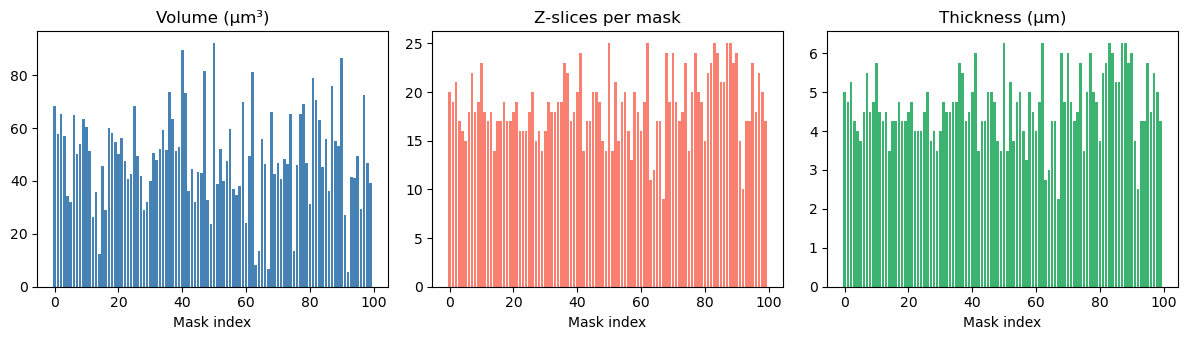

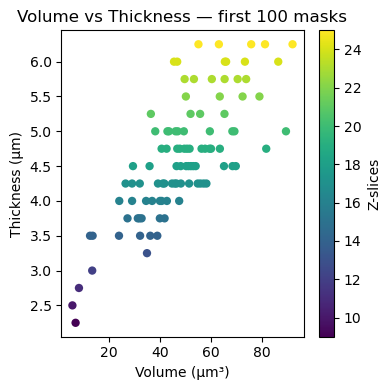

In [ ]:
# ================================================================
# Fast GPU-based Z-thickness computation per label
# ================================================================

import numpy as np
import cupy as cp
import tifffile as tiff
import time
import matplotlib.pyplot as plt

MASK_PATH = r"D:\User data\InesMarques\202501024\fish5good\fish5wholebraingood_airyscan.czi - fish5wholebraingood_airyscantile10hindbrain_400slices_onlynucleihindbrain3D_cyto3.tif"
voxel_size = (0.25, 0.10, 0.10)
voxel_volume = np.prod(voxel_size)
N_SHOW = 100

print("\n📂 Loading mask...")
t0 = time.time()
labels = tiff.imread(MASK_PATH).astype(np.int32)
print(f"   Mask shape: {labels.shape} | Load time: {time.time()-t0:.2f} s")

# --- move to GPU ---
labels_gpu = cp.asarray(labels)
nZ = labels_gpu.shape[0]
print(f"   Computing for {nZ} slices...")

# --- unique labels ---
unique_ids_gpu = cp.unique(labels_gpu)
unique_ids_gpu = unique_ids_gpu[unique_ids_gpu > 0]
max_label = int(unique_ids_gpu.max())
print(f"   Found {len(unique_ids_gpu)} labels (max ID={max_label}).")

# --- voxel count (fast volume) ---
counts_gpu = cp.bincount(labels_gpu.ravel(), minlength=max_label + 1)
volumes_gpu = counts_gpu * voxel_volume

# --- efficient Z-thickness calculation ---
z_presence_gpu = cp.zeros(max_label + 1, dtype=cp.int32)

for z in range(nZ):
    # labels that exist in this slice
    labels_in_slice = cp.unique(labels_gpu[z])
    labels_in_slice = labels_in_slice[labels_in_slice > 0]
    # mark presence (increment by 1)
    z_presence_gpu[labels_in_slice] += 1

# extract results only for existing labels
num_slices_gpu = z_presence_gpu[unique_ids_gpu]
thickness_um_gpu = num_slices_gpu * voxel_size[0]

# --- back to CPU for plotting ---
unique_ids = cp.asnumpy(unique_ids_gpu)
volumes = cp.asnumpy(volumes_gpu[unique_ids_gpu])
num_slices = cp.asnumpy(num_slices_gpu)
thickness_um = cp.asnumpy(thickness_um_gpu)

print(f"✅ Done in {time.time()-t0:.2f} s")
print(f"   Volumes: {volumes.min():.2f}–{volumes.max():.2f} µm³")
print(f"   Slices: {num_slices.min()}–{num_slices.max()}")

# --- show first N ---
subset_idx = np.arange(min(N_SHOW, len(unique_ids)))
volumes_sub = volumes[subset_idx]
slices_sub = num_slices[subset_idx]
thick_sub = thickness_um[subset_idx]


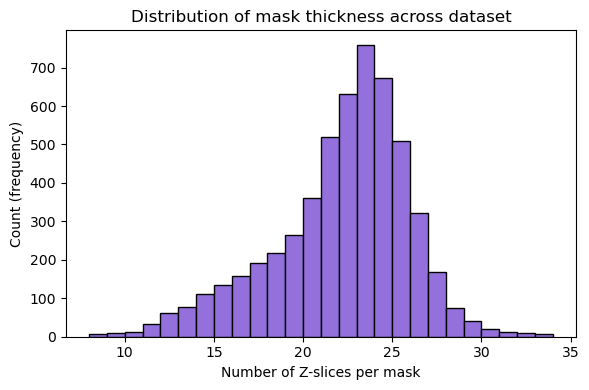

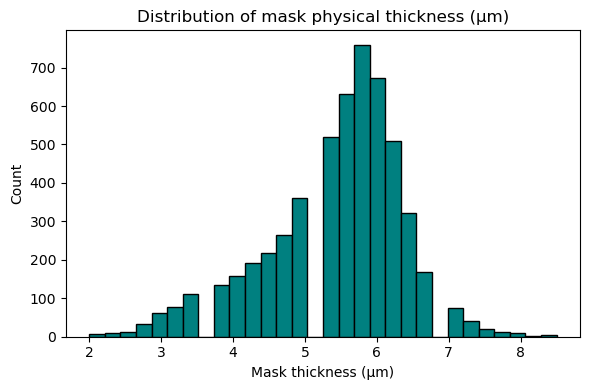

In [2]:
# ================================================================
# Histogram of Z thickness for all masks
# ================================================================

plt.figure(figsize=(6, 4))
plt.hist(num_slices, bins=np.arange(num_slices.min(), num_slices.max()+1), 
         color="mediumpurple", edgecolor="black")
plt.xlabel("Number of Z-slices per mask")
plt.ylabel("Count (frequency)")
plt.title("Distribution of mask thickness across dataset")
plt.tight_layout()
plt.show()

# Optional: same histogram in physical units
plt.figure(figsize=(6, 4))
plt.hist(thickness_um, bins=30, color="teal", edgecolor="black")
plt.xlabel("Mask thickness (µm)")
plt.ylabel("Count")
plt.title("Distribution of mask physical thickness (µm)")
plt.tight_layout()
plt.show()


In [ ]:
Grupo	Critério	Interpretação	Ação
<10 slices (<2.5 µm)	muito finas	cortes parciais / ruído	remover
10–30 slices (2.5–7.5 µm)	faixa ideal	células reais	manter
>30 slices (>7.5 µm)	muito espessas	fusões / erro de segmentação	remover

Para estas células (4.5–5 µm), um filtro de 20–100 µm³ continua sensato.

Para QC rápido em pixel-space na resolução 0.10×0.10×0.25:

diâmetro XY esperado: ~46–50 px,

espessura em Z: ~18–20 slices,

voxel count: ~19k–26k.
| Parâmetro                  | Valor         |
| -------------------------- | ------------- |
| XY step                    | 0.10 µm       |
| Z step                     | 0.25 µm       |
| Voxel volume               | 0.0025 µm³    |
| Volume esperado por célula | 40–60 µm³     |
| Voxels por célula          | 16 000–24 000 |
| Diâmetro físico            | 4–5 µm        |
| Diâmetro em píxeis         | 40–50 px      |


✅ GPU available (CuPy).

📂 Loading TIFF image and masks...
   Original shape: (400, 3, 1638, 1638)
   ✅ DsRed: (400, 1638, 1638)  |  Labels: (400, 1638, 1638)

🔄 Adjusting XY spacing to match Z-spacing (0.25 µm isotropic)...
   Scale factors: (1.0, 0.4, 0.4)
   ✅ New shape: (400, 655, 655)

📈 Base classification (P70 slice-wise + Otsu)...
   🔸 Otsu threshold = 0.509  |  DsRed+ = 1784/7898

⚡ Refinement (bounding box + DsRed+ only)...
   ✅ Refinement done: 1142 / 7898 positives (threshold=1.0)
💾 CSV saved to: D:\User data\InesMarques\2025-09-01\outcrossdsred\codigo\DsRed_comparison_P70_thr1.0.csv

🖼️ Generating Base vs Refined overlays...


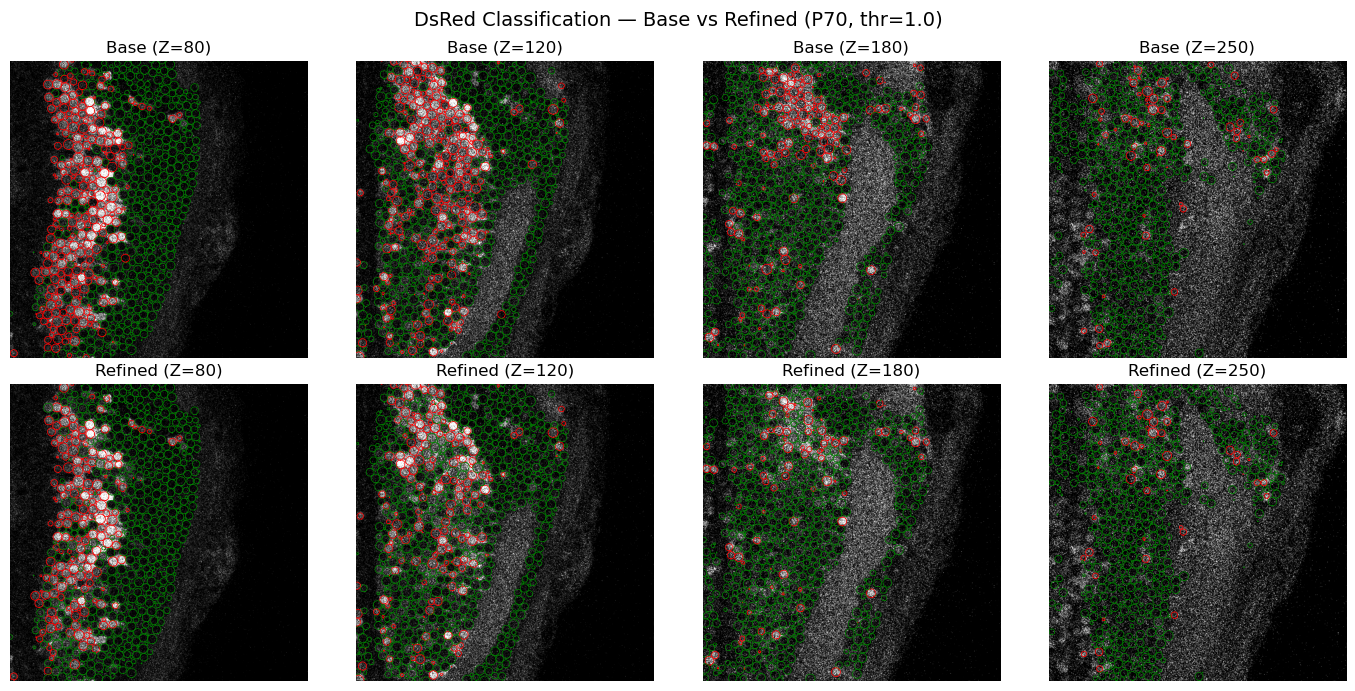


✅ Overlays for Z=80 and Z=120 completed.


In [1]:
# ================================================================
# DsRed 3D Classifier — Percentile 70 slice-wise + Central Brightness
# Optimized GPU version with bounding-box refinement and overlays
# ================================================================

import os, numpy as np, tifffile as tiff, matplotlib.pyplot as plt, pandas as pd
from skimage.filters import threshold_otsu
from skimage.measure import find_contours

# -------- GPU optional --------
try:
    import cupy as cp
    from cupyx.scipy.ndimage import zoom as cp_zoom, mean as cp_mean
    GPU = True
    print("✅ GPU available (CuPy).")
except ImportError:
    from scipy.ndimage import zoom, mean as np_mean
    GPU = False
    print("⚠️ CuPy not found, using CPU.")

# -------- CONFIG --------
IMG_PATH  = r"D:\User data\InesMarques\202501024\fish5good\fish5wholebraingood_airyscan.czi - fish5wholebraingood_airyscantile10hindbrain_400slices.tif"
MASK_PATH = r"D:\User data\InesMarques\202501024\fish5good\fish5wholebraingood_airyscan.czi - fish5wholebraingood_airyscantile10hindbrain_400slices_onlynucleihindbrain3D_cyto3_denoise_cellprob-5_masksround_round_gpu_filtered.tif"
OUT_DIR   = r"D:\User data\InesMarques\2025-09-01\outcrossdsred\codigo"
Z_SHOWS   = [80, 120, 180, 250]    # <<---- agora só estas fatias
PERCENTILE = 70
RATIO_THR  = 1.0

# ================================================================
# 1️⃣ Load image (channel 1 = DsRed) and masks
# ================================================================
print("\n📂 Loading TIFF image and masks...")

img = tiff.imread(IMG_PATH)
print("   Original shape:", img.shape)

if img.ndim == 4:
    dsred = img[:, 1, :, :].astype(np.float32)  # usa canal 1 (DsRed)
else:
    raise ValueError("⚠️ Expected a 4D image (Z, C, Y, X).")

if MASK_PATH.lower().endswith(".npy"):
    labs_raw = np.load(MASK_PATH, allow_pickle=True)
    if isinstance(labs_raw, np.ndarray) and labs_raw.dtype == object:
        labs_raw = labs_raw.item()
    labels = labs_raw.get("masks", labs_raw.get("seg", labs_raw))
    labels = np.asarray(labels, dtype=np.int32)
else:
    labels = tiff.imread(MASK_PATH).astype(np.int32)

print("   ✅ DsRed:", dsred.shape, " |  Labels:", labels.shape)

# ================================================================
# 2️⃣ Resampling — make XY match Z (0.25 µm isotropic)
# ================================================================
print("\n🔄 Adjusting XY spacing to match Z-spacing (0.25 µm isotropic)...")

voxel_orig = (0.25, 0.10, 0.10)  # (Z, Y, X)
voxel_target = (0.25, 0.25, 0.25)

scale_z = voxel_orig[0] / voxel_target[0]  # = 1.0
scale_y = voxel_orig[1] / voxel_target[1]  # = 0.4
scale_x = voxel_orig[2] / voxel_target[2]  # = 0.4
scale_factors = (scale_z, scale_y, scale_x)
print(f"   Scale factors: {scale_factors}")

if GPU:
    DsRed_gpu = cp.asarray(dsred, dtype=cp.float32)
    labels_gpu = cp.asarray(labels, dtype=cp.int32)
    DsRed_iso = cp_zoom(DsRed_gpu, scale_factors, order=1)
    labels_iso = cp_zoom(labels_gpu, scale_factors, order=0)
    DsRed_iso = cp.asnumpy(DsRed_iso)
    labels_iso = cp.asnumpy(labels_iso)
else:
    from scipy.ndimage import zoom
    DsRed_iso = zoom(dsred, scale_factors, order=1)
    labels_iso = zoom(labels, scale_factors, order=0)

print(f"   ✅ New shape: {DsRed_iso.shape}")

# ================================================================
# 3️⃣ Base classification — Percentile 70 slice-wise + Otsu
# ================================================================
print(f"\n📈 Base classification (P{PERCENTILE} slice-wise + Otsu)...")

dsred_r = DsRed_iso
labels_r = labels_iso

if GPU:
    img_gpu = cp.asarray(dsred_r, dtype=cp.float32)
    lab_gpu = cp.asarray(labels_r, dtype=cp.int32)
    ids_gpu = cp.unique(lab_gpu)[1:]
    nZ = img_gpu.shape[0]
    frac_hi_list = []
    for z in range(nZ):
        plane = img_gpu[z]
        labels_z = lab_gpu[z]
        thr_z = float(cp.percentile(plane, PERCENTILE))
        mask_hi = plane > thr_z
        frac_hi_z = cp_mean(mask_hi.astype(cp.float32), labels=labels_z, index=ids_gpu)
        frac_hi_list.append(frac_hi_z)
    frac_hi_gpu = cp.nanmean(cp.stack(frac_hi_list), axis=0)
    frac_hi, ids = cp.asnumpy(frac_hi_gpu), cp.asnumpy(ids_gpu)
else:
    ids = np.unique(labels_r)[1:]
    nZ = dsred_r.shape[0]
    frac_hi_all = []
    for z in range(nZ):
        thr_z = np.percentile(dsred_r[z], PERCENTILE)
        mask_hi = dsred_r[z] > thr_z
        frac_z = [np.mean(mask_hi[labels_r[z]==i]) for i in ids]
        frac_hi_all.append(frac_z)
    frac_hi = np.nanmean(np.stack(frac_hi_all), axis=0)

thr_otsu = threshold_otsu(frac_hi)
DsRed_base = frac_hi > thr_otsu
print(f"   🔸 Otsu threshold = {thr_otsu:.3f}  |  DsRed+ = {DsRed_base.sum()}/{len(ids)}")

# ================================================================
# 4️⃣ Refinement — bounding box + DsRed+ only
# ================================================================
print("\n⚡ Refinement (bounding box + DsRed+ only)...")

"""
📘 EXPLICAÇÃO DO 'REFINEMENT'
------------------------------------------------------------
O refinamento serve para eliminar falsos positivos
(ou seja, máscaras que são brilhantes nas bordas mas não no centro).

Para cada célula (máscara):
  1. Extrai-se o volume da célula (bounding box).
  2. Calcula-se a distância do centro usando Distance Transform.
  3. Define-se uma região central ("core") e uma região periférica ("peri").
  4. Mede-se a intensidade média de DsRed nessas duas zonas.
  5. Se o centro for mais brilhante que a periferia
     (relação I_core / I_peri > threshold, aqui 1.0),
     então a célula é considerada "positiva refinada".
  6. Caso contrário, é rejeitada.
------------------------------------------------------------
Este método garante que só células com DsRed no núcleo (real signal)
são mantidas, removendo artefactos de borda.
"""

if GPU:
    from cupyx.scipy.ndimage import distance_transform_edt
    img_gpu = cp.asarray(dsred_r, dtype=cp.float32)
    lab_gpu = cp.asarray(labels_r, dtype=cp.int32)
    ids_gpu = cp.asarray(ids, dtype=cp.int32)
    mask_pos_gpu = cp.asarray(DsRed_base)
    ratio_center_gpu = cp.full_like(ids_gpu, cp.nan, dtype=cp.float32)
    pos_labels = ids_gpu[mask_pos_gpu]

    for i in pos_labels:
        mask = (lab_gpu == i)
        if not cp.any(mask):
            continue
        z, y, x = cp.where(mask)
        z0, z1 = int(z.min()), int(z.max()) + 1
        y0, y1 = int(y.min()), int(y.max()) + 1
        x0, x1 = int(x.min()), int(x.max()) + 1
        submask = mask[z0:z1, y0:y1, x0:x1]
        subimg  = img_gpu[z0:z1, y0:y1, x0:x1]
        dist = distance_transform_edt(submask)
        dmax = float(dist.max())
        if dmax < 2:
            continue
        core_mask = dist >= (2 * dmax / 3)
        peri_mask = (dist < (dmax / 3)) & submask
        if not cp.any(core_mask) or not cp.any(peri_mask):
            continue
        I_core = subimg[core_mask].mean()
        I_peri = subimg[peri_mask].mean()
        idx = cp.where(ids_gpu == i)[0][0]
        ratio_center_gpu[idx] = I_core / (I_peri + 1e-6)
    ratio_center = cp.asnumpy(ratio_center_gpu)
else:
    from scipy.ndimage import distance_transform_edt
    ratio_center = np.full(len(ids), np.nan, dtype=np.float32)
    pos_labels = ids[DsRed_base]
    for i in pos_labels:
        mask = (labels_r == i)
        if not np.any(mask):
            continue
        z, y, x = np.where(mask)
        z0, z1 = int(z.min()), int(z.max()) + 1
        y0, y1 = int(y.min()), int(y.max()) + 1
        x0, x1 = int(x.min()), int(x.max()) + 1
        submask = mask[z0:z1, y0:y1, x0:x1]
        subimg  = dsred_r[z0:z1, y0:y1, x0:x1]
        dist = distance_transform_edt(submask)
        dmax = float(dist.max())
        if dmax < 2:
            continue
        core_mask = dist >= (2 * dmax / 3)
        peri_mask = (dist < (dmax / 3)) & submask
        if not np.any(core_mask) or not np.any(peri_mask):
            continue
        I_core = subimg[core_mask].mean()
        I_peri = subimg[peri_mask].mean()
        idx = np.where(ids == i)[0][0]
        ratio_center[idx] = I_core / (I_peri + 1e-6)

DsRed_refined = (DsRed_base) & (ratio_center > RATIO_THR)
print(f"   ✅ Refinement done: {np.sum(DsRed_refined)} / {len(ids)} positives (threshold={RATIO_THR})")

# ================================================================
# 5️⃣ Save results + overlays only
# ================================================================
df = pd.DataFrame({
    "label": ids,
    "frac_hi": frac_hi,
    "ratio_center": ratio_center,
    "DsRed_base": DsRed_base,
    "DsRed_refined": DsRed_refined
})
os.makedirs(OUT_DIR, exist_ok=True)
csv_path = os.path.join(OUT_DIR, f"DsRed_comparison_P{PERCENTILE}_thr{RATIO_THR}.csv")
df.to_csv(csv_path, index=False)
print(f"💾 CSV saved to: {csv_path}")

# ================================================================
# 6️⃣ Overlay comparison — Base vs Refined (Z=80 e 120)
# ================================================================
print("\n🖼️ Generating Base vs Refined overlays...")

def normalize01(a):
    p1, p99 = np.percentile(a, (1, 99))
    return np.clip((a - p1) / (p99 - p1 + 1e-9), 0, 1)

fig, axes = plt.subplots(2, len(Z_SHOWS), figsize=(3.5 * len(Z_SHOWS), 7))
for j, Z in enumerate(Z_SHOWS):
    if Z >= dsred_r.shape[0]:
        continue
    img_raw = normalize01(dsred_r[Z])
    ax1 = axes[0, j]
    ax1.imshow(img_raw, cmap="gray")
    for r in df.itertuples():
        color = "red" if r.DsRed_base else "green"
        mask = labels_r[Z] == r.label
        for c in find_contours(mask, 0.5):
            ax1.plot(c[:, 1], c[:, 0], color=color, lw=0.5)
    ax1.set_title(f"Base (Z={Z})")
    ax1.axis("off")
    ax2 = axes[1, j]
    ax2.imshow(img_raw, cmap="gray")
    for r in df.itertuples():
        color = "red" if r.DsRed_refined else "green"
        mask = labels_r[Z] == r.label
        for c in find_contours(mask, 0.5):
            ax2.plot(c[:, 1], c[:, 0], color=color, lw=0.5)
    ax2.set_title(f"Refined (Z={Z})")
    ax2.axis("off")

plt.suptitle(f"DsRed Classification — Base vs Refined (P{PERCENTILE}, thr={RATIO_THR})", fontsize=14)
plt.tight_layout()
plt.show()

print("\n✅ Overlays for Z=80 and Z=120 completed.")
